In [2]:
# Instala o kaggle para baixar o dataset
!pip install kaggle -q

# Cria a pasta e faz o download
!mkdir -p /content/data

# Cola sua kaggle.json aqui (veja instruções abaixo)
!kaggle datasets download -d olistbr/brazilian-ecommerce -p /content/data --unzip

Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
License(s): CC-BY-NC-SA-4.0
100% 42.6M/42.6M [00:02<00:00, 18.9MB/s]



In [4]:
from google.colab import files
import os

# Upload do arquivo kaggle.json
uploaded = files.upload()

# Pega o nome do arquivo enviado
kaggle_file = list(uploaded.keys())[0]

# Cria pasta do Kaggle
os.makedirs('/root/.kaggle', exist_ok=True)

# Move o arquivo para a pasta correta
!cp "{kaggle_file}" /root/.kaggle/kaggle.json

# Ajusta permissões
!chmod 600 /root/.kaggle/kaggle.json

print("Kaggle configurado com sucesso!")

Saving olist_customers_dataset.csv (2).zip to olist_customers_dataset.csv (2).zip
Kaggle configurado com sucesso!


In [5]:
from __future__ import print_function
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
plt.rcParams['figure.figsize'] = (12,5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("muted")
DATA = Path("/content/data")
orders =  pd.read_csv(DATA/ "olist_orders_dataset.csv", parse_dates = ["order_purchase_timestamp"])
items = pd.read_csv(DATA / "olist_order_items_dataset.csv")
customers    = pd.read_csv(DATA / "olist_customers_dataset.csv")
payments     = pd.read_csv(DATA / "olist_order_payments_dataset.csv")
reviews      = pd.read_csv(DATA / "olist_order_reviews_dataset.csv")
products     = pd.read_csv(DATA / "olist_products_dataset.csv")
categories   = pd.read_csv(DATA / "product_category_name_translation.csv")

print("Dados_carregados")
print(f"Pedidos: {len(orders)}")

Dados_carregados
Pedidos: 99441


In [6]:
payments

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


In [ ]:
from google import colab
items.to_excel("items.xlsx", index = False)
from google.colab import files
files.download("items.xlsx")


In [7]:
pedidos_entregues = orders[orders['order_status'] == "delivered"].copy()
df = (
pedidos_entregues

    .merge(items,        on = "order_id")
    .merge(customers,    on = "customer_id")
    .merge(products,      on= "product_id")
    .merge(categories,    on = "product_category_name", how = "left")
    .merge(
        payments.groupby("order_id")["payment_value"].sum().reset_index(),
                                                      on = "order_id"
    )

)
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,...,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery,28.62


In [8]:
df["mes"] = df["order_purchase_timestamp"].dt.to_period("M")
df["ano"] = df["order_purchase_timestamp"].dt.year
df["ano"]
print(f"Dataset final:{df.shape[0]:,} linhas, {df.shape[1]} colunas")

Dataset final:110,194 linhas, 30 colunas


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

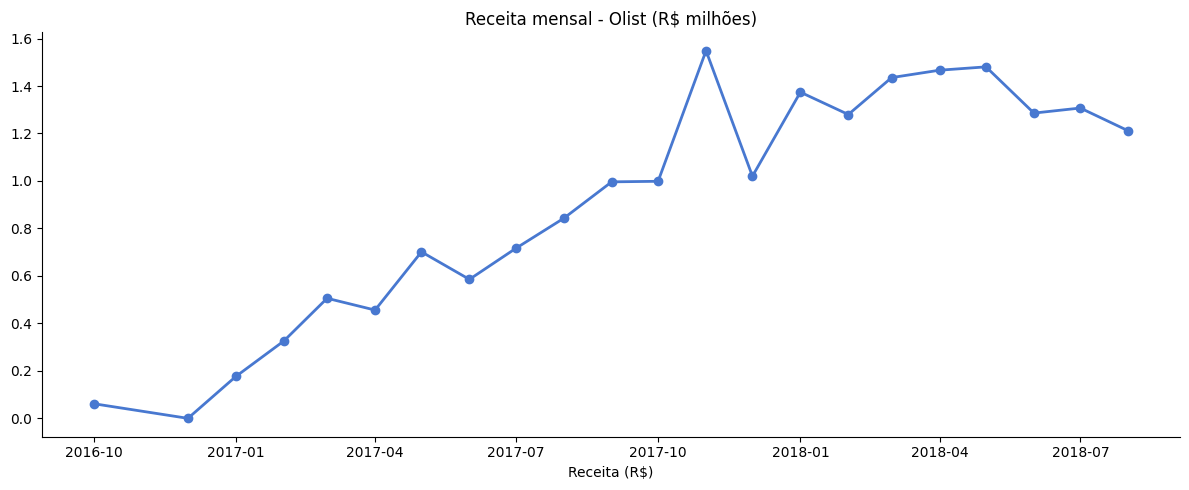

In [23]:
receita_mensal = df.groupby("mes")["payment_value"].sum().reset_index()
receita_mensal["mensal"] = receita_mensal["mes"].dt.to_timestamp()

fig, ax = plt.subplots()
ax.plot(receita_mensal["mensal"], receita_mensal["payment_value"] / 1e6,  marker = "o", linewidth = 2)
ax.set_title("Receita mensal - Olist (R$ milhões)")
ax.set_xlabel("Receita (R$)")
plt.tight_layout()
plt.savefig("/content/top_categorias.png", dpi =150 )
plt.show()


#


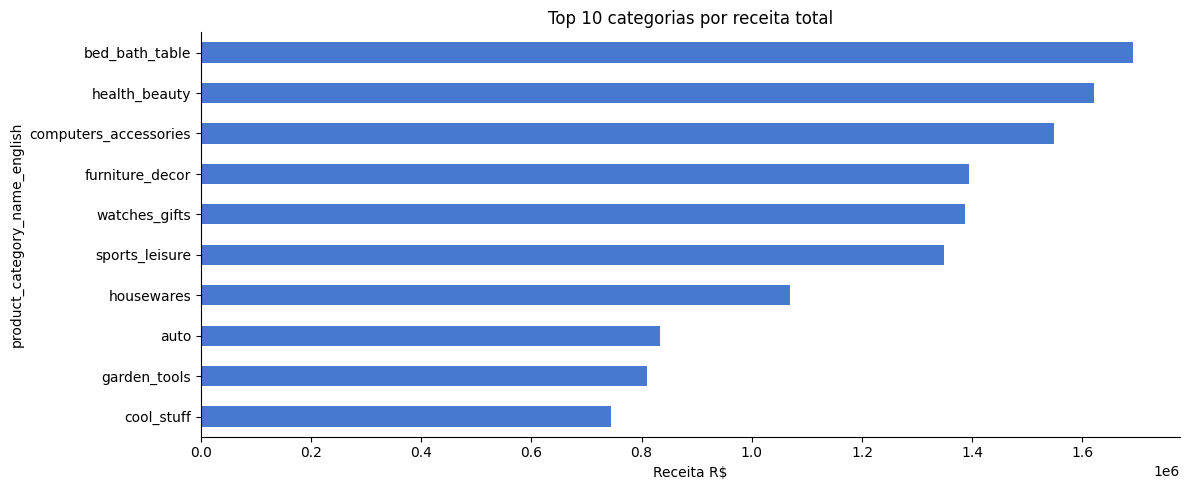

In [22]:
#Top 10 receitas
top_10_receita_por_produto = (
    df.groupby("product_category_name_english")["payment_value"].sum().sort_values(ascending=   True).tail(10)
)
top_10_receita_por_produto
fig, ax = plt.subplots()
top_10_receita_por_produto.plot(kind="barh", ax = ax)
ax.set_title("Top 10 categorias por receita total")
ax.set_xlabel("Receita R$")
plt.tight_layout()

plt.show()

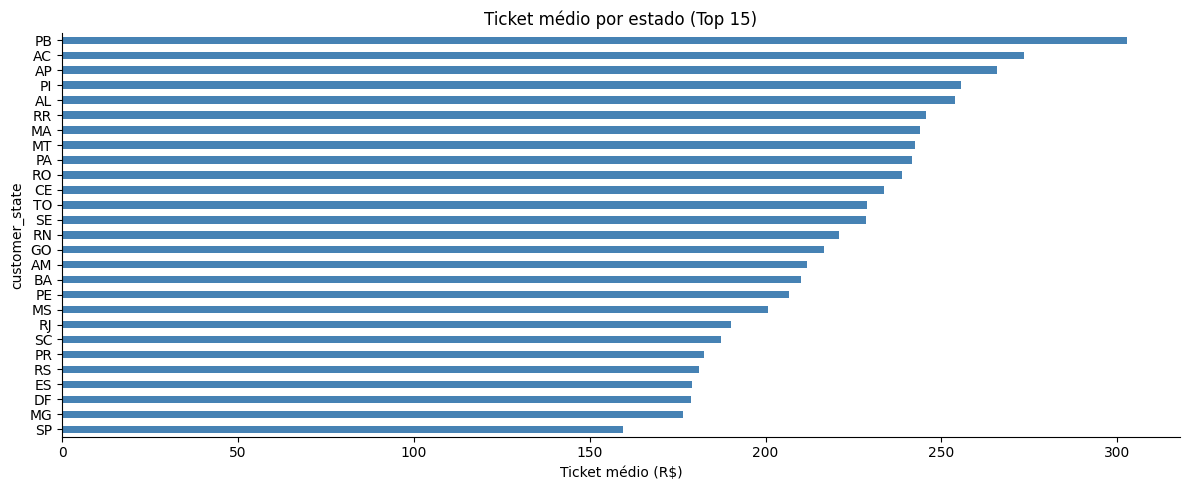

In [21]:
ticket_medio = df.groupby("customer_state")["payment_value"].mean().sort_values(ascending= True)
ticket_medio

fig, ax = plt.subplots()
ticket_medio.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Ticket médio por estado (Top 15)")
ax.set_xlabel("Ticket médio (R$)")
plt.tight_layout()
plt.savefig("/content/ticket_estado.png", dpi=150)
plt.show()

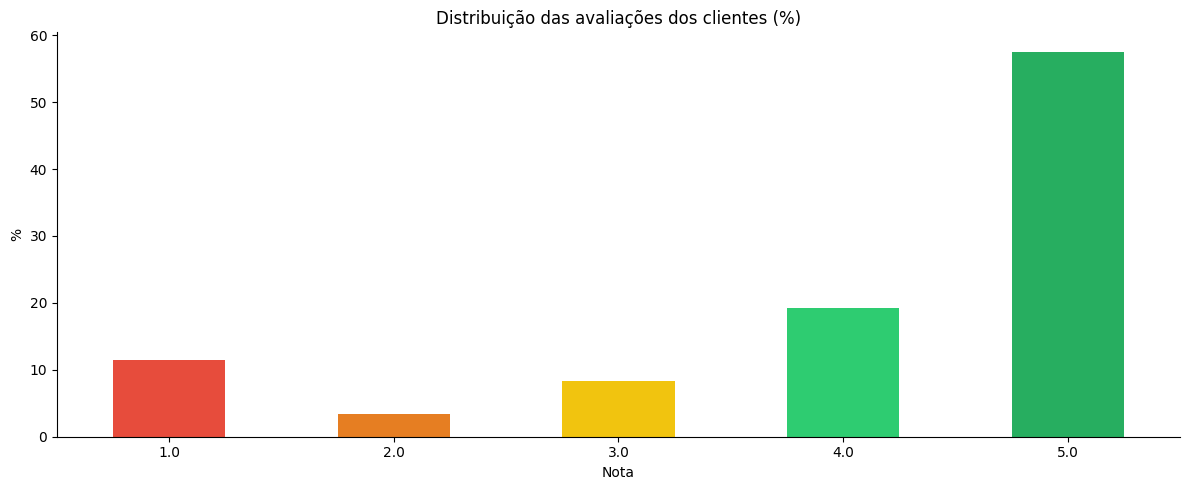

review_score
1.0    11.428052
2.0     3.363331
3.0     8.401054
4.0    19.256431
5.0    57.551132
Name: proportion, dtype: float64


In [33]:
df_rev = df.merge(reviews[["order_id", "review_score"]], on= "order_id", how = "left").sort_index(ascending= False)
score_pct = df_rev["review_score"].value_counts(normalize= True).sort_index() * 100
fig, ax = plt.subplots()
score_pct.plot(kind="bar", ax=ax, color=["#e74c3c","#e67e22","#f1c40f","#2ecc71","#27ae60"])
ax.set_title("Distribuição das avaliações dos clientes (%)")
ax.set_xlabel("Nota")
ax.set_ylabel("%")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig("/content/avaliacoes.png", dpi=150)
plt.show()

print(score_pct)

In [47]:
total_faturado = df["payment_value"].sum()
tictek_mean = df["payment_value"].mean()
estado_top = df.groupby("customer_state")["payment_value"].idxmax()
categoria_soma = df.groupby("product_category_name_english")["payment_value"].sum()
nota_media      = df_rev["review_score"].mean()

print("=" * 45)
print("  RESUMO EXECUTIVO — OLIST 2016-2018")
print("=" * 45)
print(f"  Receita total:       R$ {total_faturado:,.0f}")
print(f"  Ticket médio:        R$ {tictek_mean:.2f}")
print(f"  Estado líder:        {estado_top}")
print(f"  Categoria líder:     {categoria_soma}")
print(f"  Nota média clientes: {nota_media:.2f} / 5.0")
print("=" * 45)

  RESUMO EXECUTIVO — OLIST 2016-2018
  Receita total:       R$ 19,776,160
  Ticket médio:        R$ 179.47
  Estado líder:        customer_state
AC     63185
AL     62044
AM     78547
AP     71884
BA     75656
CE     38082
DF      8430
ES     73724
GO     51065
MA      6271
MG     35834
MS     24539
MT     56851
PA     94957
PB     44678
PE     37511
PI    102575
PR      3028
RJ     14764
RN     43914
RO    109652
RR     40158
RS     73932
SC     17770
SE     66790
SP      3848
TO     19336
Name: payment_value, dtype: int64
  Categoria líder:     product_category_name_english
agro_industry_and_commerce     115632.24
air_conditioning                88849.72
art                             28498.45
arts_and_craftmanship            2326.17
audio                           60181.00
                                 ...    
stationery                     308674.31
tablets_printing_image          10042.93
telephony                      469890.57
toys                           603564.32
watches